# Causal Inference for AI — Week 4
## Double/Debiased Machine Learning & Meta-Learners

Week 3's AIPW lets the nuisance functions $\hat e(x)$ and $\hat\mu_t(x)$ be *any* regressor.
But plug in a flexible, **regularized** ML model and a subtle problem appears: the
regularization bias of the nuisance estimates **leaks** into the causal estimate, and the
estimate becomes **overfit** to its own training data.

The fix has two ingredients, due to Chernozhukov et al. (2018):

1. **Neyman-orthogonal scores** — moment conditions insensitive to small nuisance errors
   (AIPW is one!).
2. **Cross-fitting** — estimate nuisances and evaluate the score on *disjoint* folds.

Together they give **Double Machine Learning (DML)**: $\sqrt n$-consistent, asymptotically
normal causal estimates *on top of* arbitrary ML. We build it from scratch with gradient
boosting / random forests as the nuisance learners, then survey the **meta-learner** family
(S-, T-, X-learners).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier, RandomForestRegressor
print('sklearn learners imported')

Environment ready — NumPy 2.4.4


sklearn learners imported


In [2]:
def make_partially_linear(n=6000, d=10, seed=0):
    '''Partially linear model: Y = theta*T + g(X) + eps,  T = m(X) + eta.
       Known constant treatment effect theta; nonlinear confounding g, m.'''
    rng = default_rng(seed)
    X = rng.normal(0,1,(n,d))
    g = np.sin(X[:,0]) + 0.5*X[:,1]**2 + X[:,2]*X[:,3]   # nonlinear confounding
    m = 0.5*X[:,0] + 0.3*X[:,1] - 0.4*X[:,2]             # propensity index (linear here)
    e = 1/(1+np.exp(-m))
    T = (rng.uniform(size=n) < e).astype(int)
    theta = 1.5                                          # TRUE effect
    Y = theta*T + g + rng.normal(0,1,n)
    return X, T, Y, theta

X, T, Y, THETA = make_partially_linear()
naive = Y[T==1].mean() - Y[T==0].mean()
print(f"True effect theta : {THETA:.3f}")
print(f"Naive diff-means  : {naive:.3f}  (confounded)")

True effect theta : 1.500
Naive diff-means  : 1.726  (confounded)


## 1. Why naive plug-in fails: regularization bias

Suppose we regress $Y$ on $T$ and a *single* ML prediction $\hat g(X)$. The boosting model
$\hat g$ is biased (it must be — that's how regularization buys variance reduction), and
because the *same* data trained $\hat g$ and is scored, the bias correlates with the
residuals. The estimated $\hat\theta$ inherits a $O(1)$ bias that does **not** shrink at the
$\sqrt n$ rate. We demonstrate the failure first, then the fix.

In [3]:
def naive_plugin(X, T, Y):
    # Fit g_hat = E[Y|X] on ALL data, then regress residualized Y on T (no residualizing T).
    g_hat = GradientBoostingRegressor(max_depth=3, n_estimators=200,
                                      learning_rate=.05).fit(X, Y).predict(X)
    resid_Y = Y - g_hat
    # OLS of resid_Y on T
    Td = np.column_stack([np.ones(len(T)), T])
    beta, *_ = np.linalg.lstsq(Td, resid_Y, rcond=None)
    return beta[1]

theta_naive = naive_plugin(X, T, Y)
print(f"True theta              : {THETA:.3f}")
print(f"Naive ML plug-in theta  : {theta_naive:.3f}  (regularization + overfit bias)")

True theta              : 1.500
Naive ML plug-in theta  : 1.282  (regularization + overfit bias)


## 2. Double Machine Learning with cross-fitting

The **partially-linear DML** estimator residualizes **both** $Y$ and $T$ on $X$ using
cross-fitted ML, then regresses one residual on the other (the Robinson/Frisch–Waugh
transform):

$$ \tilde Y_i = Y_i - \hat\ell(x_i),\quad \tilde T_i = T_i - \hat m(x_i),\qquad
   \hat\theta = \frac{\sum_i \tilde T_i \tilde Y_i}{\sum_i \tilde T_i^2}. $$

with $\hat\ell=\mathbb E[Y\mid X]$, $\hat m=\mathbb E[T\mid X]$ fit on folds *excluding*
unit $i$. The score $\psi=(\tilde Y-\theta\tilde T)\tilde T$ is **Neyman-orthogonal**, so
small nuisance errors enter only at *second* order.

In [4]:
def cross_fit_predict(X, y, make_model, K=5, seed=1):
    '''Return out-of-fold predictions: each point predicted by a model NOT trained on it.'''
    rng = default_rng(seed)
    idx = rng.permutation(len(y))
    folds = np.array_split(idx, K)
    oof = np.zeros(len(y), float)
    for k in range(K):
        test = folds[k]
        train = np.concatenate([folds[j] for j in range(K) if j != k])
        model = make_model()
        model.fit(X[train], y[train])
        pred = model.predict(X[test])
        if hasattr(model, "predict_proba"):
            pred = model.predict_proba(X[test])[:,1]
        oof[test] = pred
    return oof

def dml_partially_linear(X, T, Y, K=5):
    l_hat = cross_fit_predict(X, Y,
        lambda: GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=.05), K)
    m_hat = cross_fit_predict(X, T.astype(float),
        lambda: GradientBoostingRegressor(max_depth=3, n_estimators=200, learning_rate=.05), K)
    Yt = Y - l_hat
    Tt = T - m_hat
    theta = (Tt @ Yt) / (Tt @ Tt)
    # influence-function SE
    psi = (Yt - theta*Tt)*Tt
    J = -(Tt @ Tt)/len(Tt)
    inf = psi / (-J)
    se = inf.std(ddof=1)/np.sqrt(len(inf))
    return theta, se

theta_dml, se_dml = dml_partially_linear(X, T, Y)
print(f"True theta            : {THETA:.3f}")
print(f"DML (cross-fitted)    : {theta_dml:.3f}  ±{1.96*se_dml:.3f}")
print(f"95% CI                : [{theta_dml-1.96*se_dml:.3f}, {theta_dml+1.96*se_dml:.3f}]")
print(f"Naive ML plug-in      : {theta_naive:.3f}  (for comparison)")

True theta            : 1.500
DML (cross-fitted)    : 1.473  ±0.066
95% CI                : [1.407, 1.538]
Naive ML plug-in      : 1.282  (for comparison)


### Monte-Carlo: DML is centered and normal, naive plug-in is biased

We re-simulate many datasets and compare the sampling distributions. DML should sit on the
truth with approximately Gaussian spread; the naive plug-in should be visibly off-center.

DML   : mean 1.486, sd 0.049  (truth 1.5)
Naive : mean 1.224, sd 0.047


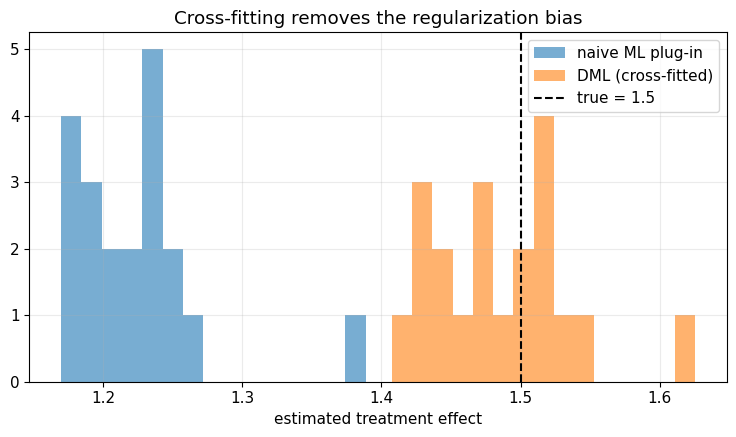

In [5]:
dml_draws, naive_draws = [], []
for s in range(20):                 # modest count: each draw fits several boosters
    Xs, Ts, Ys, th = make_partially_linear(n=2500, seed=100+s)
    dml_draws.append(dml_partially_linear(Xs, Ts, Ys, K=4)[0])
    naive_draws.append(naive_plugin(Xs, Ts, Ys))
dml_draws = np.array(dml_draws); naive_draws = np.array(naive_draws)

print(f"DML   : mean {dml_draws.mean():.3f}, sd {dml_draws.std():.3f}  (truth {THETA})")
print(f"Naive : mean {naive_draws.mean():.3f}, sd {naive_draws.std():.3f}")

plt.hist(naive_draws, bins=15, alpha=.6, label="naive ML plug-in")
plt.hist(dml_draws,   bins=15, alpha=.6, label="DML (cross-fitted)")
plt.axvline(THETA, color="k", ls="--", label=f"true = {THETA}")
plt.title("Cross-fitting removes the regularization bias")
plt.xlabel("estimated treatment effect"); plt.legend()
plt.tight_layout(); plt.savefig("../figures/w4_dml_mc.png", dpi=110); plt.show()

## 3. DML for the AIPW score (interactive model)

When the effect can depend on $X$, we use the AIPW/doubly-robust score with cross-fitted
$\hat e$, $\hat\mu_0$, $\hat\mu_1$. This is **DML with the AIPW score** and targets the ATE
under heterogeneity.

In [6]:
def dml_aipw(X, T, Y, K=5):
    n = len(Y)
    e  = cross_fit_predict(X, T,
        lambda: GradientBoostingClassifier(max_depth=3, n_estimators=150, learning_rate=.05), K)
    e = np.clip(e, 0.02, 0.98)
    mu = np.zeros((n,2))
    rng = default_rng(0); idx = rng.permutation(n); folds = np.array_split(idx, K)
    for k in range(K):
        test = folds[k]; train = np.concatenate([folds[j] for j in range(K) if j!=k])
        for t in (0,1):
            tr_t = train[T[train]==t]
            mdl = GradientBoostingRegressor(max_depth=3, n_estimators=150, learning_rate=.05)
            mdl.fit(X[tr_t], Y[tr_t])
            mu[test, t] = mdl.predict(X[test])
    score = (mu[:,1]-mu[:,0]) + T*(Y-mu[:,1])/e - (1-T)*(Y-mu[:,0])/(1-e)
    return score.mean(), score.std(ddof=1)/np.sqrt(n)

ate_dml, se = dml_aipw(X, T, Y)
print(f"True effect (constant)  : {THETA:.3f}")
print(f"DML-AIPW ATE            : {ate_dml:.3f}  ±{1.96*se:.3f}")

True effect (constant)  : 1.500
DML-AIPW ATE            : 1.496  ±0.067


## 4. Meta-learners: S, T, and X

Meta-learners are recipes that turn any regressor into a CATE estimator
$\hat\tau(x)=\hat{\mathbb E}[Y(1)-Y(0)\mid X=x]$.

- **S-learner**: one model on $(X,T)$; predict with $T{=}1$ vs $T{=}0$, subtract. Simple but
  can *regularize away* a weak treatment.
- **T-learner**: two separate models $\hat\mu_1,\hat\mu_0$; subtract. Wastes data, high
  variance in small arms.
- **X-learner**: T-learner, then impute individual effects and regress them, weighting by
  the propensity. Strong when arms are imbalanced.

We implement all three and prepare to evaluate them on heterogeneous effects next week.

In [7]:
def s_learner(X, T, Y, Xeval, make=lambda: GradientBoostingRegressor(max_depth=3,n_estimators=200,learning_rate=.05)):
    m = make().fit(np.column_stack([X, T]), Y)
    p1 = m.predict(np.column_stack([Xeval, np.ones(len(Xeval))]))
    p0 = m.predict(np.column_stack([Xeval, np.zeros(len(Xeval))]))
    return p1 - p0

def t_learner(X, T, Y, Xeval, make=lambda: GradientBoostingRegressor(max_depth=3,n_estimators=200,learning_rate=.05)):
    m1 = make().fit(X[T==1], Y[T==1]); m0 = make().fit(X[T==0], Y[T==0])
    return m1.predict(Xeval) - m0.predict(Xeval)

def x_learner(X, T, Y, Xeval, e):
    base = lambda: GradientBoostingRegressor(max_depth=3,n_estimators=200,learning_rate=.05)
    m1 = base().fit(X[T==1], Y[T==1]); m0 = base().fit(X[T==0], Y[T==0])
    # impute individual treatment effects within each arm
    D1 = Y[T==1] - m0.predict(X[T==1])
    D0 = m1.predict(X[T==0]) - Y[T==0]
    tau1 = base().fit(X[T==1], D1).predict(Xeval)
    tau0 = base().fit(X[T==0], D0).predict(Xeval)
    g = np.clip(e, .02, .98)
    return g*tau0 + (1-g)*tau1     # propensity-weighted combination

# On this constant-effect data, all should hover near THETA on average.
e_hat = cross_fit_predict(X, T,
    lambda: GradientBoostingClassifier(max_depth=3,n_estimators=150,learning_rate=.05))
e_hat = np.clip(e_hat,.02,.98)
for name, fn in [("S", lambda: s_learner(X,T,Y,X)),
                 ("T", lambda: t_learner(X,T,Y,X)),
                 ("X", lambda: x_learner(X,T,Y,X,e_hat))]:
    tau = fn()
    print(f"{name}-learner mean CATE: {tau.mean():.3f}   (true {THETA})")

S-learner mean CATE: 1.425   (true 1.5)


T-learner mean CATE: 1.488   (true 1.5)


X-learner mean CATE: 1.483   (true 1.5)


## Summary & what's next

- Naive ML plug-in suffers **regularization + overfitting bias** that does not vanish at the
  $\sqrt n$ rate — we saw it miss the true effect systematically.
- **Double Machine Learning** combines **Neyman-orthogonal** scores (AIPW/Robinson) with
  **cross-fitting**; our Monte-Carlo showed DML recentred on the truth with near-Gaussian
  spread while the naive estimator stayed biased.
- We built both the **partially-linear** DML and the **DML-AIPW** ATE estimator from scratch
  on top of gradient boosting.
- The **S/T/X meta-learners** turn any regressor into a CATE estimator — the launchpad for
  heterogeneous effects.

**Exercises.** (1) Vary the number of folds $K$ and study bias/variance. (2) Swap boosting
for a linear nuisance model and show DML still works if the linear model happens to be
correct. (3) Add a near-positivity-violating propensity and watch DML-AIPW's CI widen.

**Week 5:** from average to **individual** — estimating and *evaluating* heterogeneous
treatment effects with **Causal Forests** and **uplift** metrics.